# Análise de países

Análise exploratória de indicadores econômicos e sociais de diferentes países.

**Fonte dos dados:** Kaggle

## 1. Importação das bibliotecas

In [3]:
#importações
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns

## 2. Carregamento dos dados

In [4]:
df = pd.read_csv("../datasets/countries-of-the-world.csv")
df.head()


,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%)
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0"
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0"


## 3. Exploração e tratamento dos dados

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    str    
 1   Region                              227 non-null    str    
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    str    
 5   Coastline (coast/area ratio)        227 non-null    str    
 6   Net migration                       224 non-null    str    
 7   Infant mortality (per 1000 births)  224 non-null    str    
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 17.9 KB


In [6]:
# Dicionário de tradução das colunas
traducao_colunas = {
    'Country': 'Pais',
    'Region': 'Regiao',
    'Population': 'Populacao',
    'Area (sq. mi.)': 'Area_km2',
    'Pop. Density (per sq. mi.)': 'Densidade_Demografica',
    'Coastline (coast/area ratio)': 'Litoral_Area',
    'Net migration': 'Migracao_Liquida',
    'Infant mortality (per 1000 births)': 'Mortalidade_Infantil',
    'GDP ($ per capita)': 'PIB_per_capita',
    'Literacy (%)': 'Alfabetizacao_Pct'
}

# Aplicando a renomeação
df = df.rename(columns=traducao_colunas)

# Verificando o resultado
df.head()

,Pais,Regiao,Populacao,Area_km2,Densidade_Demografica,Litoral_Area,Migracao_Liquida,Mortalidade_Infantil,PIB_per_capita,Alfabetizacao_Pct
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0"
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0"


In [7]:
df.isnull().sum()

Pais                      0
Regiao                    0
Populacao                 0
Area_km2                  0
Densidade_Demografica     0
Litoral_Area              0
Migracao_Liquida          3
Mortalidade_Infantil      3
PIB_per_capita            1
Alfabetizacao_Pct        18
dtype: int64

In [8]:
# Lista das colunas que precisam ser convertidas para float
colunas_para_converter = [
    "Densidade_Demografica",
    "Litoral_Area",
    "Migracao_Liquida",
    "Mortalidade_Infantil",
    "Alfabetizacao_Pct"
]

for col in colunas_para_converter:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Exibe o resultado atualizado dos tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pais                   227 non-null    str    
 1   Regiao                 227 non-null    str    
 2   Populacao              227 non-null    int64  
 3   Area_km2               227 non-null    int64  
 4   Densidade_Demografica  227 non-null    float64
 5   Litoral_Area           227 non-null    float64
 6   Migracao_Liquida       224 non-null    float64
 7   Mortalidade_Infantil   224 non-null    float64
 8   PIB_per_capita         226 non-null    float64
 9   Alfabetizacao_Pct      209 non-null    float64
dtypes: float64(6), int64(2), str(2)
memory usage: 17.9 KB


In [9]:
#Tratamento de nulos
nulos = ["Migracao_Liquida",
"Mortalidade_Infantil",
"PIB_per_capita",
"Alfabetizacao_Pct"]

for i in nulos:
    #Usar mediana da mesma regiao
    df[i] = df.groupby("Regiao")[i].transform(lambda x: x.fillna(x.median()))
    #Usar mediana global caso nao tenha na regiao
    df[i] = df[i].fillna(df[i].median())
df.isnull().sum()

Pais                     0
Regiao                   0
Populacao                0
Area_km2                 0
Densidade_Demografica    0
Litoral_Area             0
Migracao_Liquida         0
Mortalidade_Infantil     0
PIB_per_capita           0
Alfabetizacao_Pct        0
dtype: int64

## 4. PIB per capita por região

Quais regiões têm maior PIB per capita médio?

In [10]:
pib_medio = df.groupby("Regiao")["PIB_per_capita"].mean().sort_values(ascending=False)
print(pib_medio)

Regiao
WESTERN EUROPE                         27046.428571
NORTHERN AMERICA                       26100.000000
BALTICS                                11300.000000
NEAR EAST                              10456.250000
EASTERN EUROPE                          9808.333333
LATIN AMER. & CARIB                     8682.222222
OCEANIA                                 8247.619048
ASIA (EX. NEAR EAST)                    8053.571429
NORTHERN AFRICA                         5550.000000
C.W. OF IND. STATES                     4000.000000
SUB-SAHARAN AFRICA                      2323.529412
Name: PIB_per_capita, dtype: float64


In [11]:
vezes_maior = pib_medio.iloc[0] / pib_medio.iloc[-1]

print(vezes_maior)

11.640235081374323


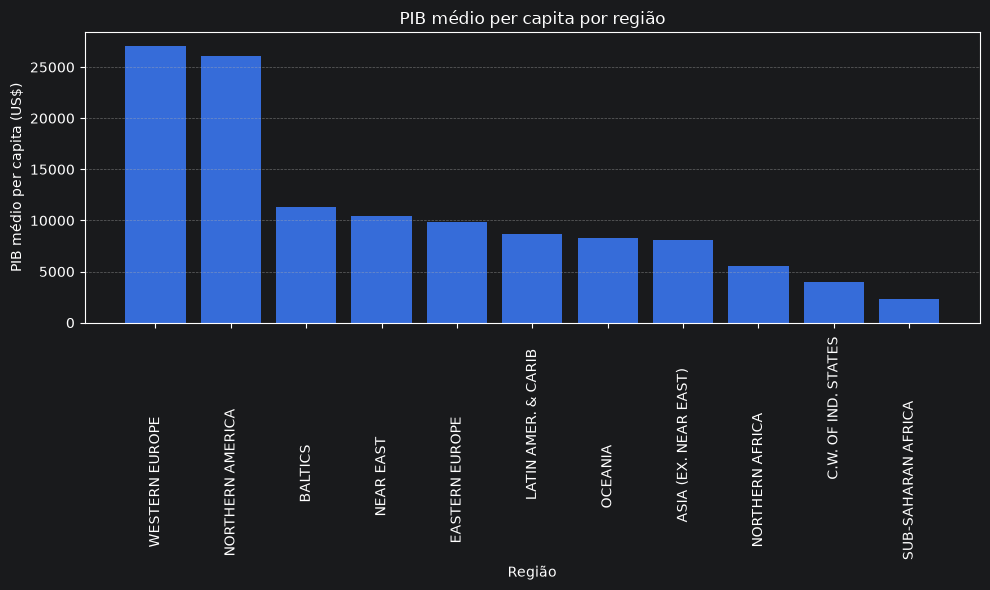

In [12]:
plt.figure(figsize=(10,6))
plt.bar(pib_medio.index, pib_medio.values)

plt.title("PIB médio per capita por região")
plt.xlabel("Região")
plt.ylabel("PIB médio per capita (US$)")

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Observa-se uma concentração de renda nas regiões da Europa Ocidental e América do Norte, que apresentam os maiores valores médios de PIB per capita. Em contraste, a África Subsaariana possui o menor PIB médio entre as regiões analisadas. A Europa Ocidental apresenta um PIB per capita médio aproximadamente 11 vezes maior que o da África Subsaariana, evidenciando uma grande desigualdade econômica entre essas regiões.

## 5. Alfabetização vs. PIB per capita

Países com maior alfabetização possuem maior PIB per capita?

In [13]:
x = df["Alfabetizacao_Pct"]
y = df["PIB_per_capita"]
r, p_value = stats.pearsonr(x, y)
inclinacao, interseccao, r_valor, p_valor, erro_padrao = stats.linregress(x, y)

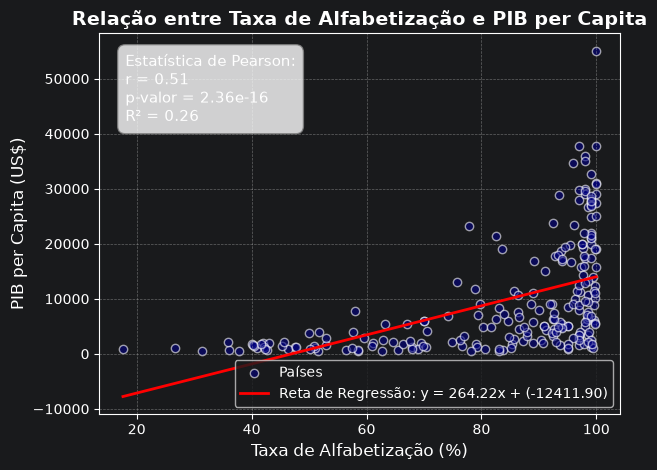

In [14]:
plt.Figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.6, color='navy', edgecolors='w', label='Países')

x_linha = np.linspace(x.min(), x.max(), 100)
y_linha = inclinacao * x_linha + interseccao

plt.plot(x_linha, y_linha, color='red', linewidth=2, label=f'Reta de Regressão: y = {inclinacao:.2f}x + ({interseccao:.2f})')
# Caixa de texto estatística
texto_estatistico = (
    f"Estatística de Pearson:\n"
    f"r = {r:.2f}\n"
    f"p-valor = {p_value:.2e}\n"
    f"R² = {r**2:.2f}"
)

plt.gca().text(
    0.05, 0.95, texto_estatistico, 
    transform=plt.gca().transAxes, 
    fontsize=11, 
    verticalalignment='top', 
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

# Estilização
plt.title("Relação entre Taxa de Alfabetização e PIB per Capita", fontsize=14, fontweight='bold')
plt.xlabel("Taxa de Alfabetização (%)", fontsize=12)
plt.ylabel("PIB per Capita (US$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig("../images/alfabetizacao_vs_pib.png", dpi=300)
plt.show()

In [15]:
print("--- RESULTADOS ESTATÍSTICOS ---")
print(f"• Coeficiente de Correlação (r): {r:.4f}")
print(f"• P-valor: {p_value:.4e}")
print(f"• Variância Explicada (R²): {r**2 * 100:.2f}%")
print("------------------------------")

if p_value < 0.05:
    print("• Conclusão: A relação é ESTATISTICAMENTE SIGNIFICANTE (p < 0.05).")
    print("  Evidências suficientes para afirmar que maior alfabetização se relaciona a maior PIB per capita.")
else:
    print("• Conclusão: A relação NÃO é estatisticamente significante (p >= 0.05).")

--- RESULTADOS ESTATÍSTICOS ---
• Coeficiente de Correlação (r): 0.5088
• P-valor: 2.3632e-16
• Variância Explicada (R²): 25.89%
------------------------------
• Conclusão: A relação é ESTATISTICAMENTE SIGNIFICANTE (p < 0.05).
  Evidências suficientes para afirmar que maior alfabetização se relaciona a maior PIB per capita.
